# XGBoost Fraud Detection Model

This notebook trains an XGBoost classifier using the same chronological data split and selected transaction features used for the Logistic Regression baseline.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

print("Python:", sys.version)
print("XGBoost version:", xgb.__version__)
print("Python executable:", sys.executable)

Python: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
XGBoost version: 3.3.0
Python executable: d:\ML\New Project Folder 26.07.2026\1st project\fraud-detection-platform\.venv312\Scripts\python.exe


## Locate the dataset

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRANSACTION_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_transaction.csv"
)

print("Project root:", PROJECT_ROOT)
print("Dataset exists:", TRANSACTION_PATH.exists())

Project root: d:\ML\New Project Folder 26.07.2026\1st project\fraud-detection-platform
Dataset exists: True


## Load the same features

Use the same columns as Logistic Regression so that the comparison is fair:

In [4]:
selected_columns = [
    "TransactionID",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "dist1",
    "P_emaildomain",
    "C1",
    "C2",
    "C4",
    "C5",
    "C6",
    "C8",
    "C10",
    "C11",
    "C12",
    "C13",
    "C14",
    "isFraud",
]

model_df = pd.read_csv(
    TRANSACTION_PATH,
    usecols=selected_columns,
    low_memory=False,
)

print("Dataset shape:", model_df.shape)
print(
    "Overall fraud rate:",
    round(model_df["isFraud"].mean() * 100, 2),
    "%",
)

model_df.head()

Dataset shape: (590540, 26)
Overall fraud rate: 3.5 %


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,C2,C4,C5,C6,C8,C10,C11,C12,C13,C14
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,25.0,1.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0


## Create time and amount features

In [5]:
model_df = (
    model_df
    .sort_values("TransactionDT")
    .reset_index(drop=True)
)

model_df["transaction_hour"] = (
    model_df["TransactionDT"] // 3600
) % 24

model_df["transaction_day"] = (
    model_df["TransactionDT"] // 86400
)

model_df["transaction_amount_log"] = np.log1p(
    model_df["TransactionAmt"]
)

print("Shape after feature engineering:", model_df.shape)

Shape after feature engineering: (590540, 29)


## Recreate the chronological split

In [6]:
total_rows = len(model_df)

train_end = int(total_rows * 0.70)
validation_end = int(total_rows * 0.85)

train_df = model_df.iloc[:train_end].copy()

validation_df = model_df.iloc[
    train_end:validation_end
].copy()

test_df = model_df.iloc[
    validation_end:
].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Testing rows:", len(test_df))

Training rows: 413378
Validation rows: 88581
Testing rows: 88581


## Prepare the features and target

In [8]:
target_column = "isFraud"

excluded_columns = [
    "TransactionID",
    "isFraud",
]

feature_columns = [
    column
    for column in model_df.columns
    if column not in excluded_columns
]

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Testing features:", X_test.shape)

Training features: (413378, 27)
Validation features: (88581, 27)
Testing features: (88581, 27)


## Create preprocessing

XGBoost does not require numerical scaling. We only need to handle categorical columns and preserve numerical missing values.

In [9]:
categorical_features = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
]

numerical_features = [
    column
    for column in feature_columns
    if column not in categorical_features
]

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
            ),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="__MISSING__",
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=50,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 23
Categorical features: 4


## Transform the data

Fit the preprocessor using only the training data:

In [10]:
start_time = time.time()

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_validation_processed = preprocessor.transform(
    X_validation
)

X_test_processed = preprocessor.transform(
    X_test
)

elapsed_time = time.time() - start_time

print("Training processed:", X_train_processed.shape)
print("Validation processed:", X_validation_processed.shape)
print("Testing processed:", X_test_processed.shape)

print(
    "Preprocessing time:",
    round(elapsed_time, 2),
    "seconds",
)

Training processed: (413378, 97)
Validation processed: (88581, 97)
Testing processed: (88581, 97)
Preprocessing time: 5.66 seconds


## Calculate the fraud class weight

In [11]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = (
    negative_count / positive_count
)

print("Legitimate training rows:", negative_count)
print("Fraud training rows:", positive_count)
print(
    "Scale positive weight:",
    round(scale_pos_weight, 2),
)

Legitimate training rows: 398840
Fraud training rows: 14538
Scale positive weight: 27.43


## Create the XGBoost model

In [12]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

xgb_model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Train the model

In [13]:
start_time = time.time()

xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[
        (
            X_validation_processed,
            y_validation,
        ),
    ],
    verbose=50,
)

training_time = time.time() - start_time

print(
    "Training time:",
    round(training_time, 2),
    "seconds",
)

print(
    "Best iteration:",
    xgb_model.best_iteration,
)

print(
    "Best validation score:",
    xgb_model.best_score,
)

[0]	validation_0-aucpr:0.35006
[50]	validation_0-aucpr:0.42119
[100]	validation_0-aucpr:0.44085
[150]	validation_0-aucpr:0.45268
[200]	validation_0-aucpr:0.46298
[250]	validation_0-aucpr:0.47020
[300]	validation_0-aucpr:0.48185
[350]	validation_0-aucpr:0.48763
[400]	validation_0-aucpr:0.49378
[450]	validation_0-aucpr:0.49942
[500]	validation_0-aucpr:0.50376
[550]	validation_0-aucpr:0.50657
[600]	validation_0-aucpr:0.51018
[650]	validation_0-aucpr:0.51433
[700]	validation_0-aucpr:0.51727
[750]	validation_0-aucpr:0.51904
[800]	validation_0-aucpr:0.51940
[850]	validation_0-aucpr:0.52124
[900]	validation_0-aucpr:0.52054
[932]	validation_0-aucpr:0.52078
Training time: 99.48 seconds
Best iteration: 882
Best validation score: 0.5217188320681002


## Evaluate validation ranking performance

In [14]:
validation_probabilities = (
    xgb_model.predict_proba(
        X_validation_processed
    )[:, 1]
)

validation_pr_auc = average_precision_score(
    y_validation,
    validation_probabilities,
)

validation_roc_auc = roc_auc_score(
    y_validation,
    validation_probabilities,
)

print(
    f"XGBoost validation PR-AUC: "
    f"{validation_pr_auc:.4f}"
)

print(
    f"XGBoost validation ROC-AUC: "
    f"{validation_roc_auc:.4f}"
)

XGBoost validation PR-AUC: 0.5218
XGBoost validation ROC-AUC: 0.8994


## XGBoost Validation Threshold Analysis

This section evaluates different decision thresholds using validation data. The goal is to balance fraud detection, precision and manual-review volume.

## Create the threshold table

In [15]:
thresholds = np.arange(
    0.05,
    0.96,
    0.05,
)

threshold_results = []

for threshold in thresholds:
    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions,
    ).ravel()

    threshold_results.append({
        "threshold": round(threshold, 2),
        "fraud_precision": precision_score(
            y_validation,
            predictions,
            zero_division=0,
        ),
        "fraud_recall": recall_score(
            y_validation,
            predictions,
            zero_division=0,
        ),
        "fraud_f1": f1_score(
            y_validation,
            predictions,
            zero_division=0,
        ),
        "transactions_flagged_percent": (
            predictions.mean() * 100
        ),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.round(4)

,threshold,fraud_precision,fraud_recall,fraud_f1,transactions_flagged_percent,false_positives,false_negatives,true_positives,true_negatives
0,0.05,0.0647,0.9484,0.1211,50.3765,41739,157,2885,43800
1,0.10,0.0963,0.8866,0.1738,31.6050,25299,345,2697,60240
2,0.15,0.1289,0.8300,0.2231,22.1199,17069,517,2525,68470
3,0.20,0.1623,0.7742,0.2683,16.3816,12156,687,2355,73383
4,0.25,0.1978,0.7239,0.3106,12.5704,8933,840,2202,76606
5,0.30,0.2345,0.6811,0.3489,9.9728,6762,970,2072,78777
6,0.35,0.2741,0.6410,0.3840,8.0311,5164,1092,1950,80375
7,0.40,0.3160,0.6072,0.4157,6.5985,3998,1195,1847,81541
8,0.45,0.3640,0.5769,0.4463,5.4436,3067,1287,1755,82472
9,0.50,0.4035,0.5388,0.4614,4.5856,2423,1403,1639,83116


## Find the threshold with the highest F1-score

In [16]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["fraud_f1"].idxmax()
]

best_f1_threshold = float(
    best_f1_row["threshold"]
)

print("Best F1 threshold:", best_f1_threshold)
print()
print(best_f1_row.round(4))

Best F1 threshold: 0.7

threshold                           0.7000
fraud_precision                     0.6082
fraud_recall                        0.4398
fraud_f1                            0.5105
transactions_flagged_percent        2.4836
false_positives                   862.0000
false_negatives                  1704.0000
true_positives                   1338.0000
true_negatives                  84677.0000
Name: 13, dtype: float64


## Find a business-friendly threshold

For example, find thresholds that flag no more than 5% of transactions:

In [18]:
review_capacity_candidates = (
    threshold_results_df[
        threshold_results_df[
            "transactions_flagged_percent"
        ] <= 5
    ]
    .sort_values(
        [
            "fraud_recall",
            "fraud_precision",
        ],
        ascending=False,
    )
)

review_capacity_candidates.round(4)

,threshold,fraud_precision,fraud_recall,fraud_f1,transactions_flagged_percent,false_positives,false_negatives,true_positives,true_negatives
9,0.50,0.4035,0.5388,0.4614,4.5856,2423,1403,1639,83116
10,0.55,0.4556,0.5112,0.4818,3.8530,1858,1487,1555,83681
11,0.60,0.5100,0.4862,0.4978,3.2738,1421,1563,1479,84118
12,0.65,0.5580,0.4632,0.5062,2.8505,1116,1633,1409,84423
13,0.70,0.6082,0.4398,0.5105,2.4836,862,1704,1338,84677
14,0.75,0.6695,0.4116,0.5098,2.1111,618,1790,1252,84921
15,0.80,0.7210,0.3866,0.5033,1.8413,455,1866,1176,85084
16,0.85,0.7802,0.3570,0.4899,1.5714,306,1956,1086,85233
17,0.90,0.8218,0.3123,0.4526,1.3050,206,2092,950,85333
18,0.95,0.8758,0.2597,0.4006,1.0183,112,2252,790,85427


This gives two useful options:

Best F1 threshold: best overall precision-recall balance.
Review-capacity threshold: best fraud recall while flagging no more than 5% of transactions.

## Plot threshold performance

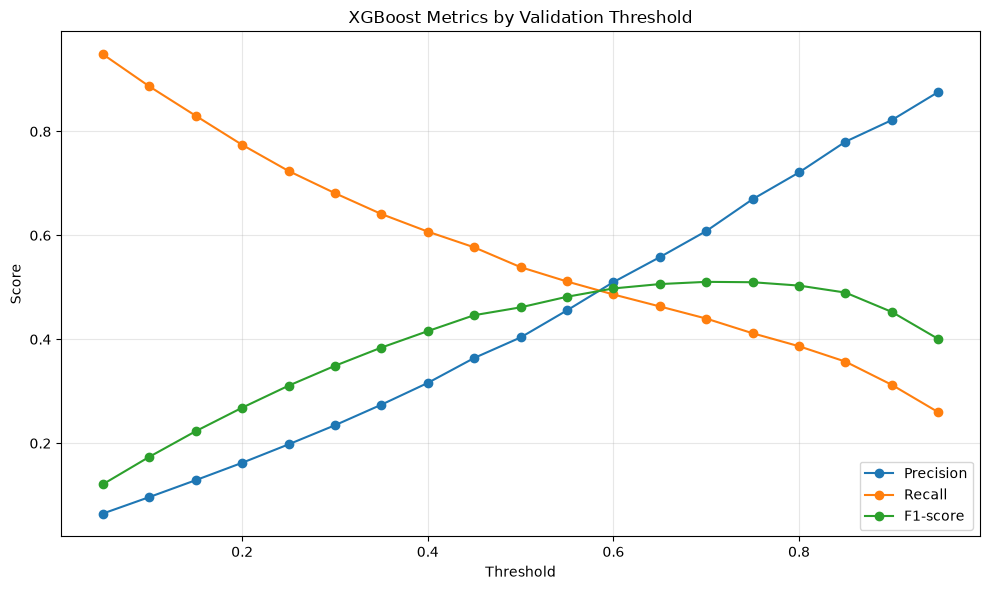

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["fraud_precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["fraud_recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["fraud_f1"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Metrics by Validation Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

0

## final XGBoost test evaluation

The test dataset has remained untouched. Now evaluate it once using the selected 0.70 threshold.

Generate test predictions

In [20]:
selected_threshold = best_f1_threshold

test_probabilities = xgb_model.predict_proba(
    X_test_processed,
    iteration_range=(
        0,
        xgb_model.best_iteration + 1,
    ),
)[:, 1]

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

print("Selected threshold:", selected_threshold)

print(
    "Test transactions flagged:",
    round(test_predictions.mean() * 100, 2),
    "%",
)

Selected threshold: 0.7
Test transactions flagged: 2.55 %


## Calculate test PR-AUC and ROC-AUC

In [21]:
test_pr_auc = average_precision_score(
    y_test,
    test_probabilities,
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities,
)

print(f"XGBoost test PR-AUC: {test_pr_auc:.4f}")
print(f"XGBoost test ROC-AUC: {test_roc_auc:.4f}")

XGBoost test PR-AUC: 0.4572
XGBoost test ROC-AUC: 0.8801


## Generate the classification report

In [22]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Legitimate",
            "Fraud",
        ],
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9789    0.9883    0.9835     85498
       Fraud     0.5563    0.4084    0.4710      3083

    accuracy                         0.9681     88581
   macro avg     0.7676    0.6983    0.7273     88581
weighted avg     0.9642    0.9681    0.9657     88581



## Generate the confusion matrix

In [23]:
test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
)

test_confusion_matrix_table = pd.DataFrame(
    test_confusion_matrix,
    index=[
        "Actual Legitimate",
        "Actual Fraud",
    ],
    columns=[
        "Predicted Legitimate",
        "Predicted Fraud",
    ],
)

test_confusion_matrix_table

,Predicted Legitimate,Predicted Fraud
Actual Legitimate,84494,1004
Actual Fraud,1824,1259


## Add a comparison table

After getting the test outputs, add:

In [24]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "XGBoost",
    ],
    "test_pr_auc": [
        0.1874,
        test_pr_auc,
    ],
    "test_roc_auc": [
        0.7683,
        test_roc_auc,
    ],
    "selected_threshold": [
        0.85,
        selected_threshold,
    ],
    "transactions_flagged_percent": [
        5.79,
        test_predictions.mean() * 100,
    ],
    "fraud_precision": [
        0.1753,
        precision_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
    ],
    "fraud_recall": [
        0.2916,
        recall_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
    ],
    "fraud_f1": [
        0.2189,
        f1_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
    ],
})

model_comparison.round(4)

,model,test_pr_auc,test_roc_auc,selected_threshold,transactions_flagged_percent,fraud_precision,fraud_recall,fraud_f1
0,Logistic Regression,0.1874,0.7683,0.85,5.7900,0.1753,0.2916,0.2189
1,XGBoost,0.4572,0.8801,0.70,2.5547,0.5563,0.4084,0.4710
